In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
superstore_dataframe = pd.read_csv("../data/input/superstore.csv", encoding="latin1")

In [4]:
superstore_dataframe.head(2)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820


In [5]:
superstore_dataframe.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [6]:
# Ravesh 1
superstore_dataframe["Order Date"] = superstore_dataframe["Order Date"].astype("datetime64[us]")
superstore_dataframe["Ship Date"] = superstore_dataframe["Ship Date"].astype("datetime64[us]")
# Ravesh 2
superstore_dataframe["Order Date"] = pd.to_datetime(superstore_dataframe["Order Date"])
superstore_dataframe["Ship Date"] = pd.to_datetime(superstore_dataframe["Ship Date"])

In [7]:
superstore_dataframe.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   str           
 2   Order Date     9994 non-null   datetime64[us]
 3   Ship Date      9994 non-null   datetime64[us]
 4   Ship Mode      9994 non-null   str           
 5   Customer ID    9994 non-null   str           
 6   Customer Name  9994 non-null   str           
 7   Segment        9994 non-null   str           
 8   Country        9994 non-null   str           
 9   City           9994 non-null   str           
 10  State          9994 non-null   str           
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   str           
 13  Product ID     9994 non-null   str           
 14  Category       9994 non-null   str           
 15  Sub-Category   9994 non-null   s

In [8]:
superstore_dataframe.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [9]:
superstore_dataframe.drop_duplicates(inplace=True)

In [10]:
superstore_dataframe.duplicated().sum()

np.int64(0)

In [11]:
superstore_dataframe = superstore_dataframe.assign(
    Profit_Ratio = superstore_dataframe["Profit"] / superstore_dataframe["Sales"]
)

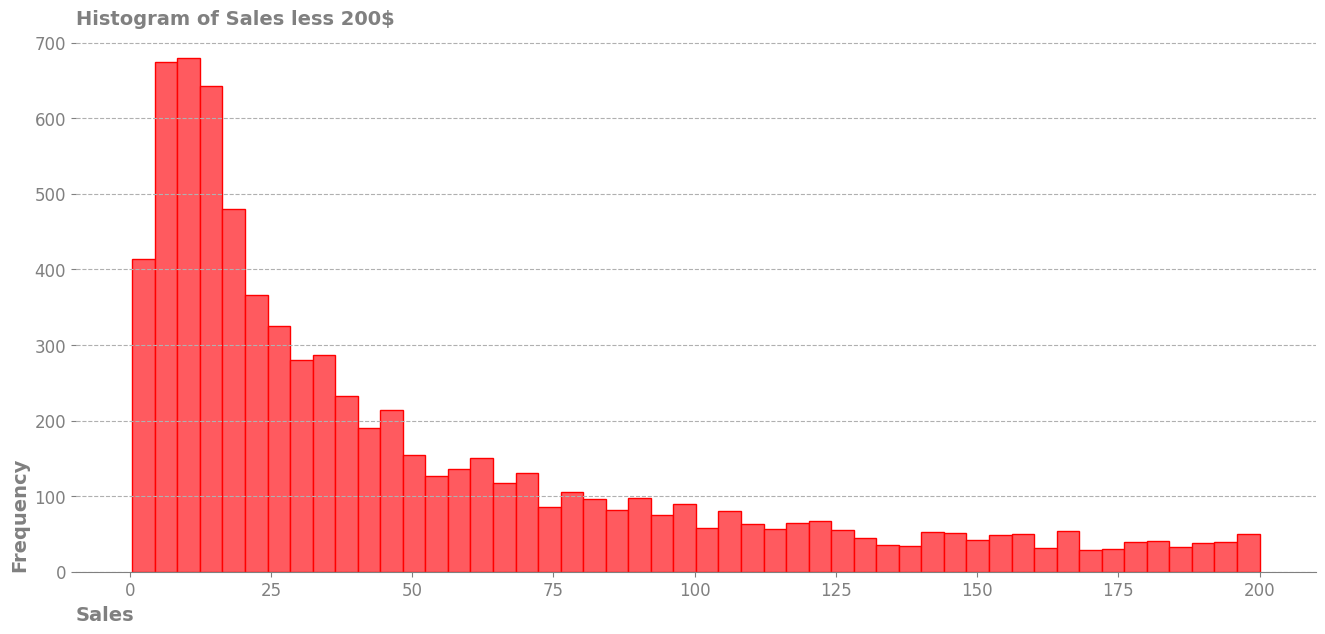

In [12]:
fig, ax=plt.subplots(figsize=(16, 7))
ax.hist(superstore_dataframe.query("Sales < 200")["Sales"].dropna(),
        bins=50,
        color="#FF5A5F",
        edgecolor="red",
        alpha=1
        )
ax.spines[["top", "right", "left"]].set_visible(False)
ax.spines[["bottom"]].set_color("gray")

ax.set_title("Histogram of Sales less 200$", loc="left", weight="bold", color="gray", fontsize=14)
ax.set_xlabel("Sales", loc="left", weight="bold", color="gray", fontsize=14)
ax.set_ylabel("Frequency", loc="bottom", weight="bold", color="gray", fontsize=14)

ax.tick_params(axis="x", colors="gray", labelsize=12)
ax.tick_params(axis="y", colors="gray", labelsize=12)

ax.grid(axis="y", linestyle="dashed")

plt.show()

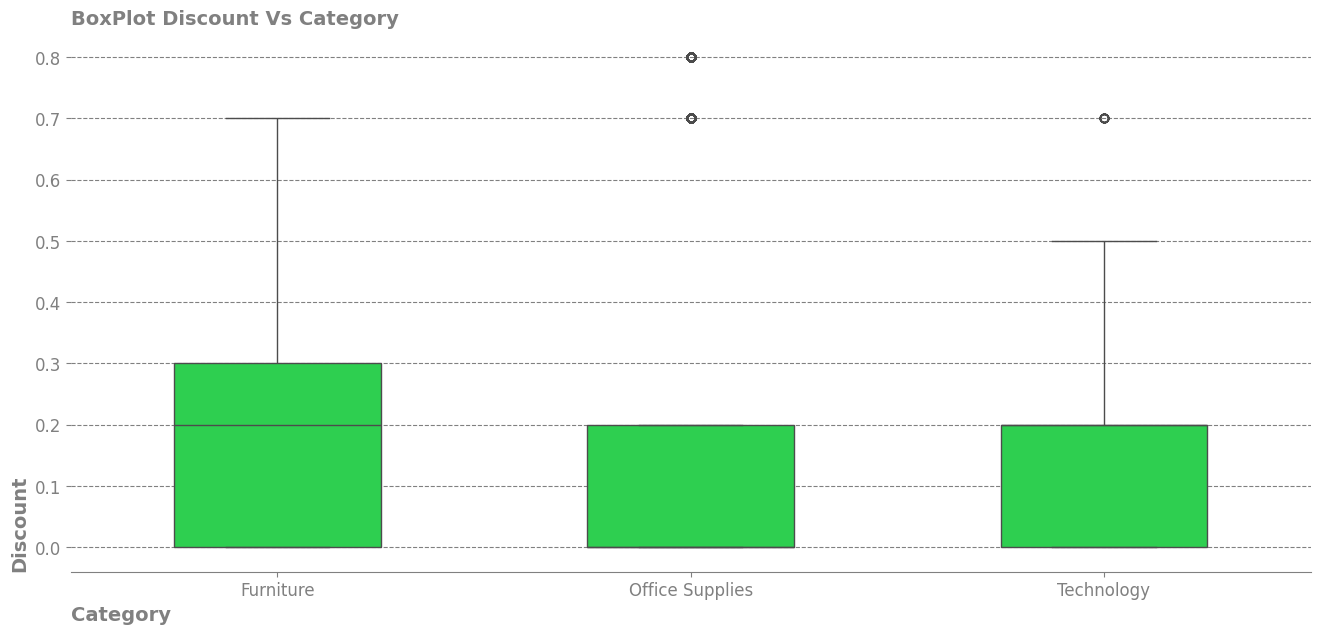

In [13]:
fig, ax=plt.subplots(figsize=(16, 7))
sns.boxplot(data=superstore_dataframe,
            x="Category",
            y="Discount",
            color="#13EA41",
            width=0.5,
            ax=ax
            )

ax.spines[["top", "right", "left"]].set_visible(False)
ax.spines[["bottom"]].set_color("gray")

ax.set_title("BoxPlot Discount Vs Category", loc="left", weight="bold", color="gray", fontsize=14)
ax.set_xlabel("Category", loc="left", weight="bold", color="gray", fontsize=14)
ax.set_ylabel("Discount", loc="bottom", weight="bold", color="gray", fontsize=14)

ax.tick_params(axis="x", colors="gray", labelsize=12)
ax.tick_params(axis="y", colors="gray", labelsize=12)

ax.grid(axis="y", color="gray", linestyle="dashed")

plt.show()

In [14]:
superstore_dataframe[["Profit", "Sales"]].describe()

,Profit,Sales
count,9994.000000,9994.000000
mean,28.656896,229.858001
std,234.260108,623.245101
min,-6599.978000,0.444000
25%,1.728750,17.280000
50%,8.666500,54.490000
75%,29.364000,209.940000
max,8399.976000,22638.480000


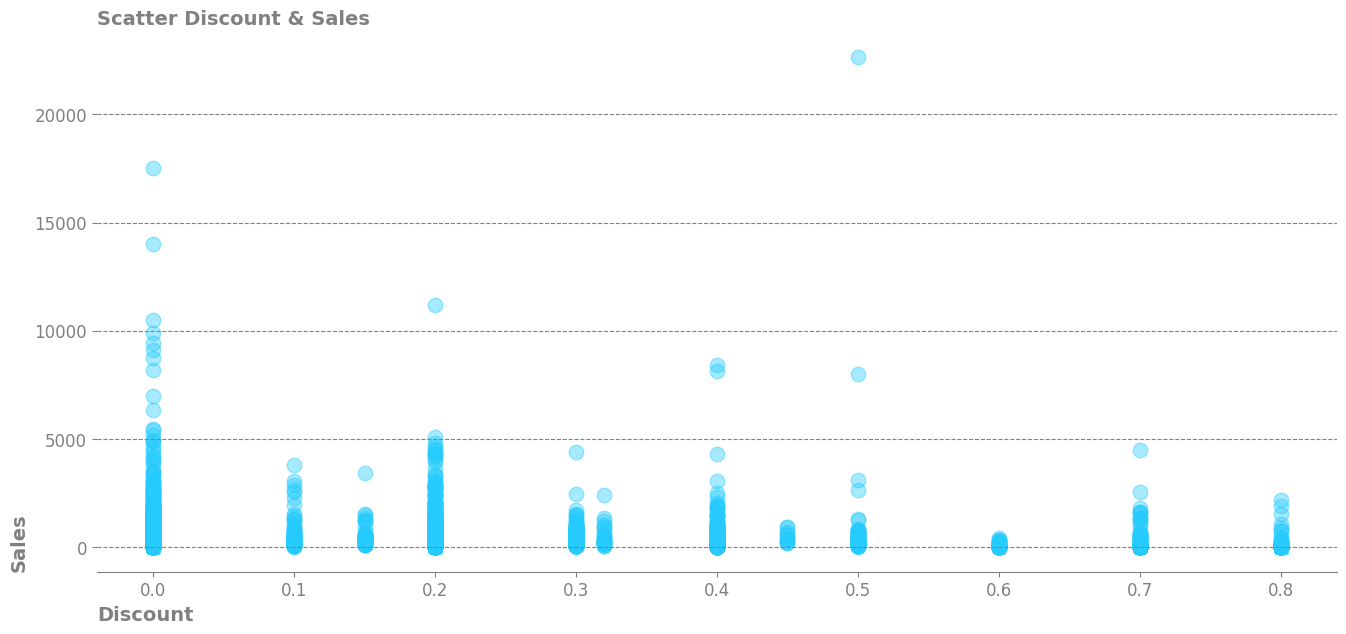

In [15]:
fig, ax=plt.subplots(figsize=(16, 7))
ax.scatter(x=superstore_dataframe["Discount"],
           y=superstore_dataframe["Sales"], 
           c="#25CBFD",
           s=110,
           alpha=0.4,
           )
ax.spines[["top", "left", "right"]].set_visible(False)
ax.spines[["bottom"]].set_color("gray")

ax.set_title("Scatter Discount & Sales", loc="left", weight="bold", color="gray", fontsize=14)
ax.set_xlabel("Discount", loc="left", weight="bold", color="gray", fontsize=14)
ax.set_ylabel("Sales", loc="bottom", weight="bold", color="gray", fontsize=14)

ax.tick_params(axis="x", colors="gray", labelsize=12)
ax.tick_params(axis="y", colors="gray", labelsize=12)

ax.grid(axis="y", color="gray", linestyle="dashed")

plt.show()

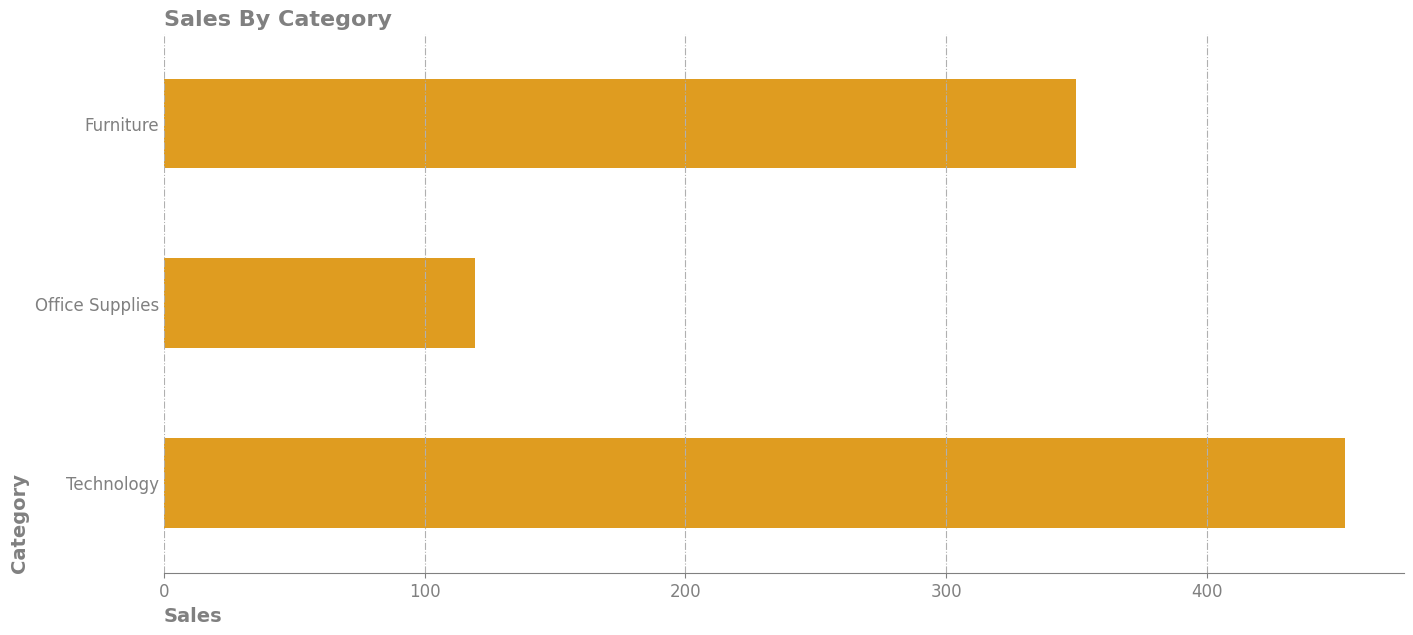

In [16]:
fig, ax=plt.subplots(figsize=(16, 7))
sns.barplot(data=superstore_dataframe,
            x="Sales",
            y="Category",
            width=0.5,
            color="orange",
            edgecolor="None",
            errorbar=None,
            ax=ax
            )
ax.spines[["top", "right", "left"]].set_visible(False)
ax.spines[["bottom"]].set_color("gray")

ax.set_title("Sales By Category", loc="left", weight="bold", color="gray", fontsize=16)
ax.set_xlabel("Sales", loc="left", weight="bold", color="gray", fontsize=14)
ax.set_ylabel("Category", loc="bottom", weight="bold", color="gray", fontsize=14)

ax.tick_params(axis="x", colors="gray", labelsize=12)
ax.tick_params(axis="y", colors="gray", which="major", length=0, labelsize=12)

ax.grid(axis="x", linestyle="dashdot")

plt.show()

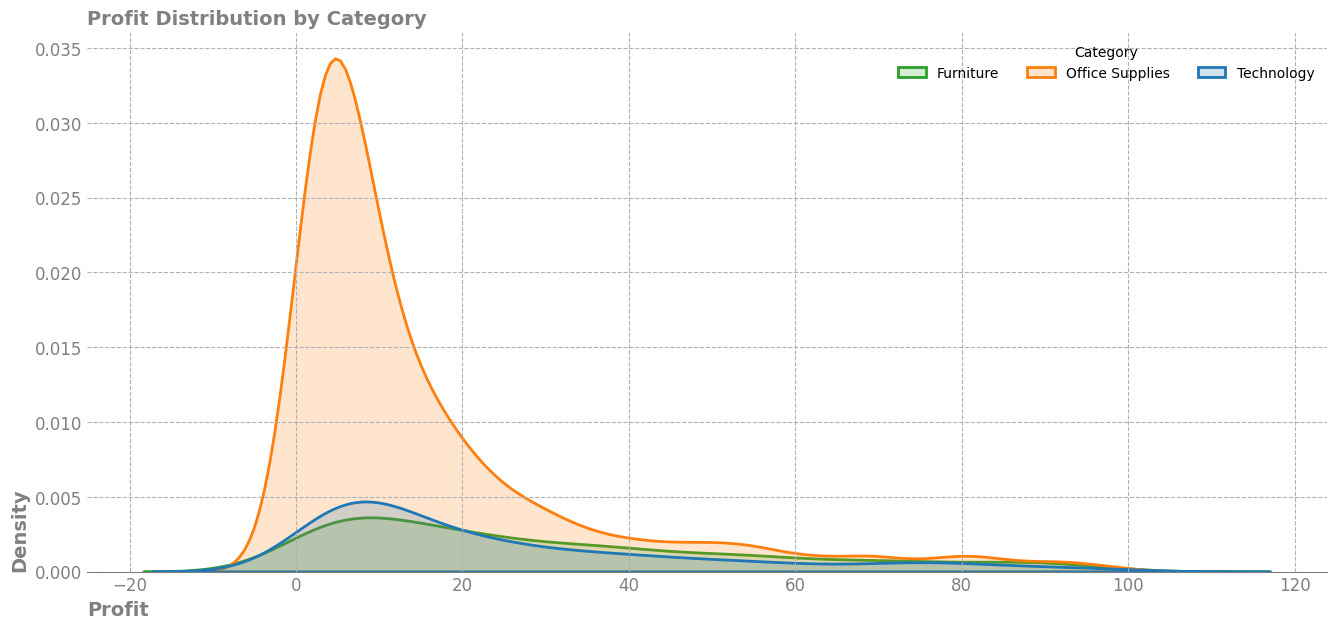

In [17]:
fig, ax=plt.subplots(figsize=(16, 7))
sns.kdeplot(data=superstore_dataframe.query("0 < Profit < 100"),
            x="Profit",
            hue="Category",
            linewidth=2,
            alpha=0.2,
            fill=True)

ax.spines[["top", "right", "left"]].set_visible(False)
ax.spines[["bottom"]].set_color("gray")

ax.set_title("Profit Distribution by Category", loc="left", weight="bold", color="gray", fontsize=14)
ax.set_xlabel("Profit", loc="left", weight="bold", color="gray", fontsize=14)
ax.set_ylabel("Density", loc="bottom", weight="bold", color="gray", fontsize=14)

ax.tick_params(axis="x", colors="gray", labelsize=12, which="major", length=0)
ax.tick_params(axis="y", colors="gray", labelsize=12, which="major", length=0)

ax.grid(axis="both", linestyle="dashed")

ax.legend(title="Category", ncol=7, labels=["Furniture", "Office Supplies", "Technology"], loc="upper right", frameon=False)

plt.show()


In [18]:
pivot_sales = pd.pivot_table(data=superstore_dataframe,
               index="Region",
               columns="Category",
               values="Sales",
               aggfunc="sum",
               fill_value=0
               )
pivot_sales.map(lambda x: f"${x:,.2f}")

Category,Furniture,Office Supplies,Technology
Region,,,
Central,"$163,797.16","$167,026.42","$170,416.31"
East,"$208,291.20","$205,516.05","$264,973.98"
South,"$117,298.68","$125,651.31","$148,771.91"
West,"$252,612.74","$220,853.25","$251,991.83"


In [19]:
sales_segment_sum = superstore_dataframe.groupby("Segment")["Sales"].sum().reset_index()
sales_segment_sum["Sales"] = sales_segment_sum["Sales"].apply(lambda x: f"${x:,.0f}")
sales_segment_sum

,Segment,Sales
0,Consumer,"$1,161,401"
1,Corporate,"$706,146"
2,Home Office,"$429,653"


In [20]:
prifit_sefment_avg = superstore_dataframe.groupby("Segment")["Profit"].mean().reset_index()
prifit_sefment_avg["Profit"] = prifit_sefment_avg["Profit"].apply(lambda x: f"${x:,.2f}")
prifit_sefment_avg

,Segment,Profit
0,Consumer,$25.84
1,Corporate,$30.46
2,Home Office,$33.82


In [21]:
superstore_dataframe.groupby("Sub-Category").agg(
    median_sales = ("Sales", "median"),
    total_profit = ("Profit", "sum")
).reset_index()

,Sub-Category,median_sales,total_profit
0,Accessories,100.00000,41936.6357
1,Appliances,82.69000,18138.0054
2,Art,15.50400,6527.7870
3,Binders,18.56000,30221.7633
4,Bookcases,306.82025,-3472.5560
5,Chairs,362.13600,26590.1663
6,Copiers,1099.98000,55617.8249
7,Envelopes,29.04600,6964.1767
8,Fasteners,10.58400,949.5182
9,Furnishings,41.96000,13059.1436


In [22]:
pd.crosstab(
    index=superstore_dataframe["Category"],
    columns=superstore_dataframe["Ship Mode"],
    values=superstore_dataframe["Sales"],
    aggfunc="sum",
    normalize=True
).mul(100)

Ship Mode,First Class,Same Day,Second Class,Standard Class
Category,,,,
Furniture,4.820237,1.704195,6.803455,18.972284
Office Supplies,4.411121,1.266345,6.994730,18.628812
Technology,6.066757,2.617266,6.191080,21.523718


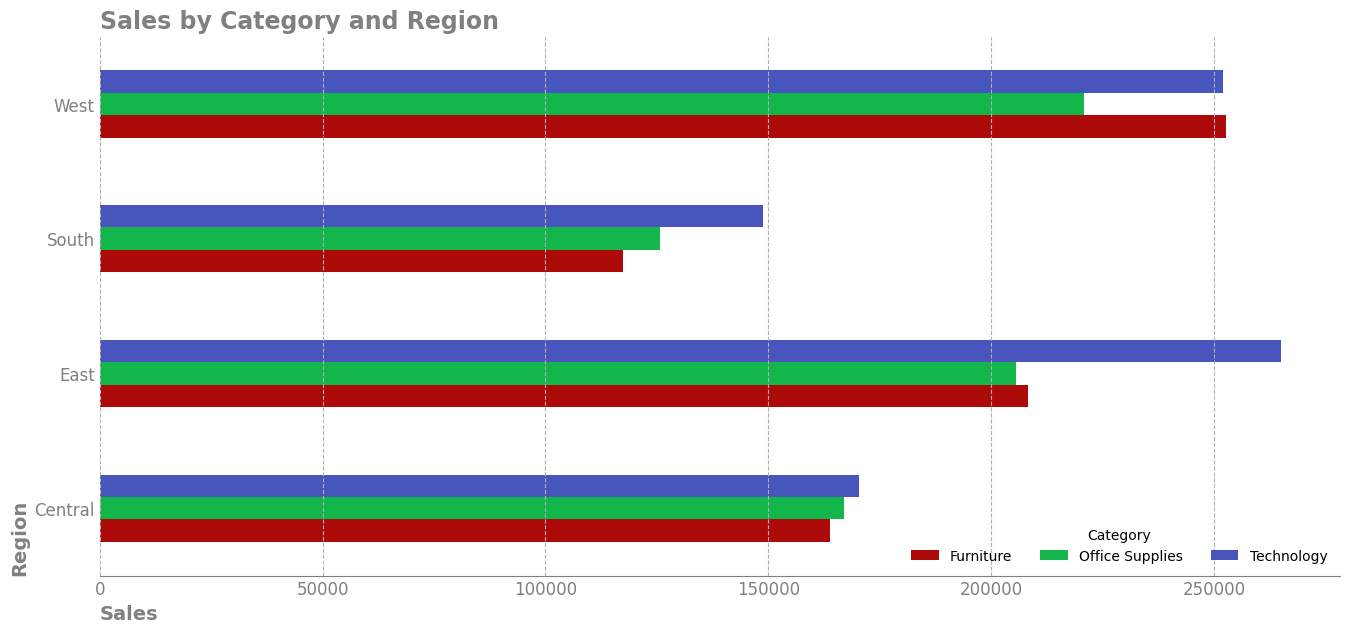

In [23]:
fig, ax=plt.subplots(figsize=(16, 7))
pivot_sales.plot(kind="barh", ax=ax, color=["#AC0909", "#12B64B", "#4755BC"])

ax.spines[["left", "right", "top"]].set_visible(False)
ax.spines[["bottom"]].set_color("gray")

ax.set_title("Sales by Category and Region", loc="left", weight="bold", color="gray", fontsize=17)
ax.set_xlabel("Sales", loc="left", weight="bold", color="gray", fontsize=14)
ax.set_ylabel("Region", loc="bottom", weight="bold", color="gray", fontsize=14)

ax.tick_params(axis="both", colors="gray", labelsize=12, which="major", length=0)

ax.grid(axis="x", linestyle="dashed")

ax.legend(title="Category", loc="lower right", ncol=8, frameon=False)


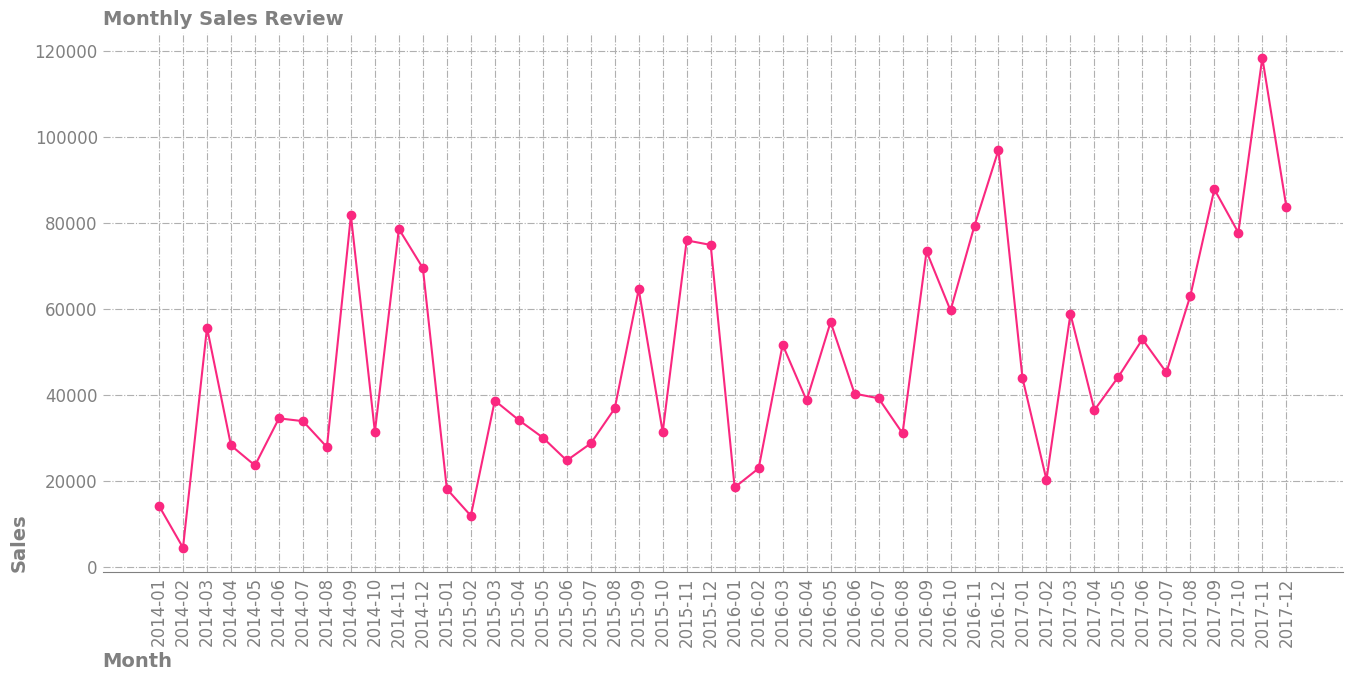

In [72]:
superstore_dataframe = superstore_dataframe.assign(
    Order_month = superstore_dataframe["Order Date"].dt.to_period("M").astype("str")
)
monthly_sales = superstore_dataframe.groupby("Order_month")["Sales"].sum().reset_index()

fig, ax=plt.subplots(figsize=(16, 7))
ax.plot(monthly_sales["Order_month"], monthly_sales["Sales"], marker="o", linestyle="-", color="#FA277F")

ax.spines[["top", "right", "left"]].set_visible(False)
ax.spines[["bottom"]].set_color("gray")

ax.set_title("Monthly Sales Review", loc="left", weight="bold", color="gray", fontsize=14)
ax.set_xlabel("Month", loc="left", weight="bold", color="gray", fontsize=14)
ax.set_ylabel("Sales", loc="bottom", weight="bold", color="gray", fontsize=14)

ax.tick_params(axis="both", colors="gray", labelsize=12, which="major", length=0)
ax.tick_params(axis="x", rotation=90)

ax.grid(axis="both", linestyle='-.')

plt.show()



In [80]:
superstore_dataframe[["Sales", "Profit", "Discount", "Quantity"]]

,Sales,Profit,Discount,Quantity
0,261.9600,41.9136,0.00,2
1,731.9400,219.5820,0.00,3
2,14.6200,6.8714,0.00,2
3,957.5775,-383.0310,0.45,5
4,22.3680,2.5164,0.20,2
...,...,...,...,...
9989,25.2480,4.1028,0.20,3
9990,91.9600,15.6332,0.00,2
9991,258.5760,19.3932,0.20,2
9992,29.6000,13.3200,0.00,4


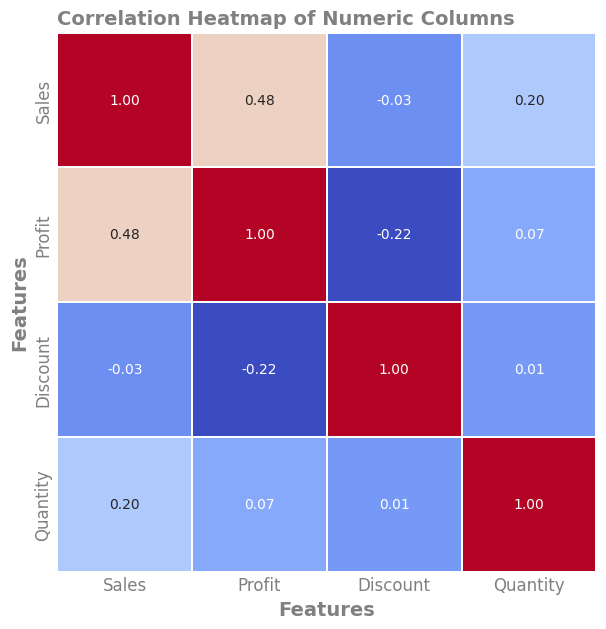

In [ ]:
numeric_cols = ["Sales", "Profit", "Discount", "Quantity"]
corr_matrix = superstore_dataframe[numeric_cols].corr()

fig, ax=plt.subplots(figsize=(16, 7))
sns.heatmap(corr_matrix,annot=True, cmap="coolwarm", fmt="0.2f", square=True, cbar=False, linewidths=0.1, ax=ax)


ax.spines[["left", "right", "top"]].set_visible(False)
ax.spines[["bottom"]].set_color("gray")

ax.set_title("Correlation Heatmap of Numeric Columns", loc="left", weight="bold", color="gray", fontsize=14)
ax.set_xlabel("Features", weight="bold", color="gray", fontsize=14)
ax.set_ylabel("Features", weight="bold", color="gray", fontsize=14)

ax.tick_params(axis="both", colors="gray", labelsize=12, which="major", length=0)

plt.show()

In [107]:
superstore_dataframe["Performace"] = superstore_dataframe["Profit"].apply(lambda x: "High Profit" if x > 100 else "Low Profit")

In [ ]:
# Ravesh1
def discount_category(Discount):
    if Discount > 0.3:
        return "Heavy Discount"
    elif 0.1 <= Discount <= 0.3:
        return "Medium Discount"
    else:
        return "Low Discount"

superstore_dataframe["Discount Category"] = superstore_dataframe["Discount"].apply(discount_category)

# Ravesh2

superstore_dataframe["Discount Category"] = superstore_dataframe["Discount"].apply(lambda x: "Hravy Discount" if x > 0.3 else("Medium Discount" if 0.1 <= x <= 0.3 else "Low Discount"))

In [113]:
superstore_dataframe.to_csv("../data/output/superstore_cleaned.csv")

In [117]:
pivot_sales.to_csv("../data/output/pivot_output.xlsx")